In [33]:
import pandas as pd
import nltk 
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk import RegexpParser
from nltk.tokenize import sent_tokenize 
from nltk import Tree
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from transformers import TFBertModel, AutoTokenizer
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cosine
from concurrent.futures import ProcessPoolExecutor
import warnings
import time
from concurrent.futures import ThreadPoolExecutor
from transformers import logging
from matplotlib.ticker import MaxNLocator
import math
from transformers import pipeline
from functools import partial
from scipy.optimize import curve_fit
import json
import itertools
import statsmodels.api as sm

import networkx as nx
import matplotlib.pyplot as plt
import os
# from pyvis.network import Network
import sknetwork
from IPython.display import SVG
from sknetwork.visualization import svg_graph
from sknetwork.ranking import PageRank
import numpy as np
from sklearn.utils import Bunch
from networkx.classes.function import density

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from itertools import combinations
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')
logging.set_verbosity_error()  # disable warnings from transformer, hugging face package.

In [34]:
## get all the stories.  nine stories in total.
story_all = [] 

data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/boyscout.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v1-pool.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v2-lake.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v1-rookie.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v2-catlady.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/panic.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v1-park.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v2-church.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/stein.pkl")
story_all.append(data)

In [35]:
## use the clauses in the original dataset.
story_processed_all = [story_all[i]['segmentation'] for i in np.arange(9)]
story_processed_marked = [string.split("\n") for string in story_processed_all]  # split into single clauses.
story_processed_all = [[item[3:] if item[2] == "." 
                        else item[2:] if item[1] == "."
                        else item[4:] for item in story_processed_marked[story]] for story in np.arange(9)]

recall_processed_all = [story_all[i]['recalls segmented'] for i in np.arange(len(story_processed_all))]
recall_processed_marked = [[participant.split("\n") for participant in recall_processed_all[story]]
                        for story in np.arange(9)]
recall_processed_all = [[ [element[3:] if len(element) > 2 and element[2] == "." else
                           element[2:] if len(element) > 2 and element[1] == "." else
                           element[4:] if len(element) > 2 else
                           ""  for element in participant] for participant in recall_processed_marked[story]]
                        for story in np.arange(9)]

score_processed_all = [story_all[i]['recall scores'] for i in np.arange(len(story_processed_all))]
for i in np.arange(len(score_processed_all)):
    recall_score_each = score_processed_all[i].values
    score_processed_all[i] = recall_score_each.tolist()


In [36]:
## three more stories added to the analysis.
story_additional = [] 
recall_additional = []

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-segments.csv", encoding='utf-8')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-recalls_segmented.csv", encoding='utf-8')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/do-something-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/dosomething-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)


In [37]:
additional_story_processed = []
additional_recall_processed = [[] for _ in np.arange(3)]
score_processed_additional = []

for i in np.arange(3):
    # the original story in segment.
    story = story_additional[i]['segment_text']
    story_as_list = story.tolist()
    additional_story_processed.append(story_as_list)

    # get the recall text by each participant.
    recall = recall_additional[i]
    recall_id = recall['recall_id']
    recall_id_set = list(set(recall_id))
    for j in recall_id_set:
        recall_participant = recall[recall['recall_id'] == j]
        recall_content = recall_participant['clause_text']
        recall_as_list = recall_content.tolist()
        additional_recall_processed[i].append(recall_as_list)

    # get the recall score of each narrative clause. - the final score in the csv directly.
    score_processed_additional.append(story_additional[i]['proc'])
    score_processed_add = [series_item.tolist() for series_item in score_processed_additional]
    score_processed = [[float(p.strip('%')) for p in percent_list] 
                                      for percent_list in score_processed_add]


In [38]:
## add the new data to the dataset.
story_processed_all = story_processed_all + additional_story_processed
recall_processed_all = recall_processed_all + additional_recall_processed

clauses = [len(story_processed_all[i]) for i in np.arange(len(story_processed_all))]
print("clauses in each story: ", clauses )

clauses in each story:  [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]


In [39]:
### look at other data in the datasets.
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/boyscout.pkl")

data.keys()

data['recall scores']  # the recalled clause in the original story for each participant. need to calculate the recall percentage myself to get the score line.

# data['recall_scores_completions']   # with the participant hash-ID, clauses and those recalled.

5aa18536dbdb470001ef2cf1            [1, 2, 5, 7, 8, 9, 10, 14, 16, 17, 19]
5f0b196928879b23ce83e097                                    [7, 9, 11, 19]
5d5db7f7ca179000180b17cc         [1, 2, 5, 6, 7, 8, 9, 10, 11, 14, 16, 18]
5ac0eabce1546900019bd744    [2, 4, 5, 6, 7, 9, 10, 11, 12, 15, 16, 17, 19]
60693e637bc58fc13d57b1a7          [6, 7, 8, 9, 10, 14, 15, 16, 17, 18, 19]
                                                 ...                      
5ea806dea2d63e011f551ef6                              [1, 6, 7, 8, 17, 19]
5d95fc8c7f79070017f92e93       [1, 2, 5, 7, 8, 10, 13, 14, 16, 17, 18, 19]
5ceef0cd45c1ec001920d548                                    [2, 5, 14, 19]
63f7792ffa2f18ec31a85d24                            [2, 3, 5, 7, 8, 9, 14]
640226e83e2c4614c50dff0e                           [2, 5, 6, 7, 9, 17, 19]
Length: 100, dtype: object

In [40]:
model = SentenceTransformer('all-MiniLM-L6-v2')
story_emb_all = [model.encode(story) for story in story_processed_all]

recall_emb_all = [[model.encode(participant) for participant in story]
                    for story in recall_processed_all]

## PCA components above noise threshold.

In [41]:
## find out eigenvalues above noise threshold.
n_permutations = 20
eigenvec = [[] for i in np.arange(12)]
n_components = clauses
n_significant = []

for i in np.arange(12):
    story_emb_centered = story_emb_all[i] - np.mean(story_emb_all[i], axis=0)
    col_std = np.std(story_emb_centered, axis=0)

    # fit PCA on real data
    pca = PCA()
    pca.fit(story_emb_centered)
    eigenvec[i] = pca.components_[:n_components[i]]
    real_eigenvalues = pca.explained_variance_[:n_components[i]]

    # noise threshold
    max_eigs = []
    for _ in np.arange(n_permutations):
        noise = np.random.randn(*story_emb_centered.shape) * col_std
        pca_noise = PCA()
        pca_noise.fit(noise)
        max_eigs.append(pca_noise.explained_variance_[0])
    threshold = np.mean(max_eigs)

    # significant components
    above = [(j+1, v) for j, v in enumerate(real_eigenvalues) if v > threshold]
    n_significant.append(len(above))
    print(f"Story {i+1}: noise threshold = {threshold:.4f} | "
          f"{len(above)} significant components eigenvalues: {[round(v,4) for _,v in above]}")

print("\nSignificant components per story:", n_significant)

Story 1: noise threshold = 0.0576 | 3 significant components eigenvalues: [0.0949, 0.0873, 0.078]
Story 2: noise threshold = 0.0606 | 4 significant components eigenvalues: [0.0861, 0.0749, 0.0694, 0.0623]
Story 3: noise threshold = 0.0621 | 3 significant components eigenvalues: [0.1, 0.0875, 0.0714]
Story 4: noise threshold = 0.0416 | 4 significant components eigenvalues: [0.0887, 0.056, 0.0529, 0.0501]
Story 5: noise threshold = 0.0419 | 5 significant components eigenvalues: [0.0706, 0.0599, 0.0565, 0.0492, 0.0475]
Story 6: noise threshold = 0.0259 | 8 significant components eigenvalues: [0.0608, 0.0536, 0.0423, 0.0369, 0.0354, 0.0309, 0.0297, 0.0266]
Story 7: noise threshold = 0.0279 | 8 significant components eigenvalues: [0.0703, 0.0583, 0.0479, 0.044, 0.0387, 0.0354, 0.0341, 0.0301]
Story 8: noise threshold = 0.0273 | 8 significant components eigenvalues: [0.0737, 0.0642, 0.0479, 0.0407, 0.0379, 0.0339, 0.0308, 0.0281]
Story 9: noise threshold = 0.0159 | 12 significant components 

In [42]:
## extract eigenvectors from the signal PCA directions.
n_components = [3, 4, 3, 4, 5, 8, 8, 8, 12, 13, 16, 10]
eigenvec = [[] for i in np.arange(12)]

for i in np.arange(12):
    story_emb_centered = story_emb_all[i] - np.mean(story_emb_all[i], axis=0)
    
    pca = PCA()
    pca.fit(story_emb_centered)
    eigenvec[i] = pca.components_[:n_components[i]]

### Align clauses with the PCA directions to give it meaning.

In [43]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

story_proj   = [[] for _ in range(12)]
salient_idx  = [[] for _ in range(12)]
salient_close = []

for i in np.arange(12):
    story_emb = story_emb_all[i]
    for index, eigen in enumerate(eigenvec[i]):
        story_proj[i].append([abs(story_emb[j] @ eigen) for j in np.arange(len(story_emb))])

for i in np.arange(12):
    rows  = []
    count = 0
    for j in np.arange(n_components[i]):
        aligned_any = False
        for k in np.arange(len(story_proj[i][j])):
            align_val = story_proj[i][j][k]
            if align_val > 0.5:
                if k not in salient_idx[i]:
                    salient_idx[i].append(k)
                aligned_any = True
                rows.append({
                    'Eigenvector': j + 1,
                    'Clause':      k + 1,
                    'Align Score': round(align_val, 3),
                    'Text':        story_processed_all[i][k],
                })
        if aligned_any:
            count += 1
    salient_close.append(round(100 * count / n_components[i], 2))

    print(f"Narrative {i+1}  —  {salient_close[-1]:.1f}% eigenvectors with ≥1 match")
    if rows:
        df_sal = pd.DataFrame(rows)[['Eigenvector', 'Clause', 'Align Score', 'Text']]
        display(df_sal.reset_index(drop=True))
    print()

# store salient clause indices per story
salient_idx_all = []
for i in range(12):
    indices = sorted(set(salient_idx[i]))
    salient_idx_all.append(indices)
    print(f"Story {i+1}: {len(indices)} salient clauses — indices {[k+1 for k in indices]}")


Narrative 1  —  100.0% eigenvectors with ≥1 match


,Eigenvector,Clause,Align Score,Text
0,1,2,0.714,"And we was doing the 50-yard dash,"
1,1,5,0.736,and so we was doing the 50-yard dash.
2,2,1,0.613,"Yeah, I was in the boy scouts at the time."
3,2,14,0.644,Scoutmaster was up there.
4,3,16,0.575,But he didn't pay me no attention either.



Narrative 2  —  75.0% eigenvectors with ≥1 match


,Eigenvector,Clause,Align Score,Text
0,1,7,0.550,and she tried to save me from being stung.
1,1,9,0.519,and I warned her to be careful.
2,2,13,0.610,"When I resurfaced, gasping for air,"
3,2,17,0.565,"and naturally, the first thing to do was to get out and dry off,"
4,4,10,0.528,"'Course friends, y'know, they don't always think things through."



Narrative 3  —  100.0% eigenvectors with ≥1 match


...


Narrative 11  —  25.0% eigenvectors with ≥1 match


,Eigenvector,Clause,Align Score,Text
0,1,106,0.522,"she said, “Mother must’ve gotten really worked up about Marie.”"
1,2,113,0.541,"I said, “Get out of here,"
2,2,114,0.527,"I’ll kick you,” I said."
3,2,121,0.562,"“Get out!” I said, “Don’t you dare come near me.”"
4,3,17,0.557,"But the nurse said, “Well, that’s the doctor’s orders.”"
5,3,98,0.528,The hospital kept calling.
6,3,116,0.535,Another nurse came over.
7,6,20,0.535,and they had to put her back in bed.
8,6,49,0.558,and I had the coat on my arm and her dress hanging on my arm.
9,6,71,0.557,And my daughter was on the bed with her bedroom slippers and her housecoat on.



Narrative 12  —  40.0% eigenvectors with ≥1 match


,Eigenvector,Clause,Align Score,Text
0,1,13,0.517,"and he's blocking off the lane,"
1,1,66,0.536,He can't keep his car on one side of the road.â
2,1,70,0.573,the guy stops way far away from the intersection.
3,1,71,0.573,"He stops,"
4,1,72,0.516,"and he throws his car into reverse,"
5,1,75,0.511,he starts backing up going backwards down that road.
6,1,77,0.514,"and he starts forward again,"
7,3,6,0.521,"and I was slowing down,"
8,3,8,0.504,"and as I was slowing down,"
9,3,62,0.588,"and I got out the car,"



Story 1: 5 salient clauses — indices [1, 2, 5, 14, 16]
Story 2: 5 salient clauses — indices [7, 9, 10, 13, 17]
Story 3: 7 salient clauses — indices [5, 7, 9, 10, 13, 14, 15]
Story 4: 1 salient clauses — indices [11]
Story 5: 2 salient clauses — indices [1, 3]
Story 6: 6 salient clauses — indices [14, 19, 21, 22, 45, 47]
Story 7: 5 salient clauses — indices [16, 22, 40, 44, 45]
Story 8: 5 salient clauses — indices [3, 5, 26, 42, 48]
Story 9: 21 salient clauses — indices [5, 16, 33, 46, 52, 54, 60, 69, 70, 71, 77, 82, 84, 85, 86, 93, 94, 97, 104, 105, 112]
Story 10: 16 salient clauses — indices [27, 29, 35, 36, 37, 54, 60, 66, 70, 73, 74, 75, 110, 111, 115, 122]
Story 11: 14 salient clauses — indices [17, 20, 49, 71, 85, 89, 92, 98, 106, 109, 113, 114, 116, 121]
Story 12: 12 salient clauses — indices [4, 6, 8, 9, 13, 62, 66, 70, 71, 72, 75, 77]


In [44]:
## mean percentage of eigenvectors matched with >= 1 clause.
mean_match_rate = np.mean(salient_close)
print(f"Mean eigenvector matching rate across stories: {mean_match_rate:.1f}%")
print(f"Per story: {salient_close}")


Mean eigenvector matching rate across stories: 51.2%
Per story: [100.0, 75.0, 100.0, 25.0, 40.0, 37.5, 37.5, 37.5, 58.33, 38.46, 25.0, 40.0]


## Recall rate of sentences aligned with main eigenvectors.

In [45]:
recall_threshold = 0.5

def calculate_recall_probability_score(index, salient_embedding):
    recall_probability = [] 
    print(f"story {index+1} start.")

    for clause in salient_embedding:
        participant_recall = 0;
        for k in np.arange(len(recall_emb_all[index])):   # i for each participant.
            for recall_clause_emb in recall_emb_all[index][k]:
                distance = cosine(recall_clause_emb, clause)
                if distance < recall_threshold:
                    participant_recall += 1.0/len(recall_emb_all[index])
                    break
        recall_probability.append(round(100*participant_recall,2))

    return recall_probability


recall_data = [[] for i in np.arange(12)]
for i in np.arange(12):
    salient_idx_narrative = salient_idx[i]
    salient_embedding = [story_emb_all[i][j] for j in salient_idx_narrative]

    ## compare with recalls and get the recall rate.
    recall_data[i] = calculate_recall_probability_score(i, salient_embedding)


all_clauses_recall = []
for i in np.arange(12):
    all_embedding = story_emb_all[i]   # all clauses, not just salient
    all_clauses_recall.append(calculate_recall_probability_score(i, all_embedding))


story 1 start.
story 2 start.
story 3 start.
story 4 start.
story 5 start.
story 6 start.
story 7 start.
story 8 start.
story 9 start.
story 10 start.
story 11 start.
story 12 start.
story 1 start.
story 2 start.
story 3 start.
story 4 start.
story 5 start.
story 6 start.
story 7 start.
story 8 start.
story 9 start.
story 10 start.
story 11 start.
story 12 start.


In [46]:
mean_recall = [np.mean(story_values) for story_values in recall_data]
se_recall_pca = [
    np.std(story_values, ddof=1) / np.sqrt(len(story_values))
    for story_values in recall_data
]

mean_all_clauses_recall = [np.mean(story_values) for story_values in all_clauses_recall]
se_recall_all = [
    np.std(story_values, ddof=1) / np.sqrt(len(story_values))
    for story_values in all_clauses_recall
]

# for i in range(12):
#     print(
#         f"Story {i+1}: "
#         f"PCA-aligned mean={mean_recall[i]:.2f}, SE={se_recall_pca[i]:.3f}  |  "
#         f"All clauses mean={mean_all_clauses_recall[i]:.2f}, SE={se_recall_all[i]:.3f}"
#     )

from scipy import stats as sp_stats

clauses_arr = np.array(clauses, dtype=float)

slope, intercept, r_value, p_value, std_err = sp_stats.linregress(
    clauses_arr, np.array(mean_recall, dtype=float)
)
slope2, intercept2, r_value2, p_value2, std_err2 = sp_stats.linregress(
    clauses_arr, np.array(mean_all_clauses_recall, dtype=float)
)


### Plot.

Paired t-test: t = 2.560, p = 0.027


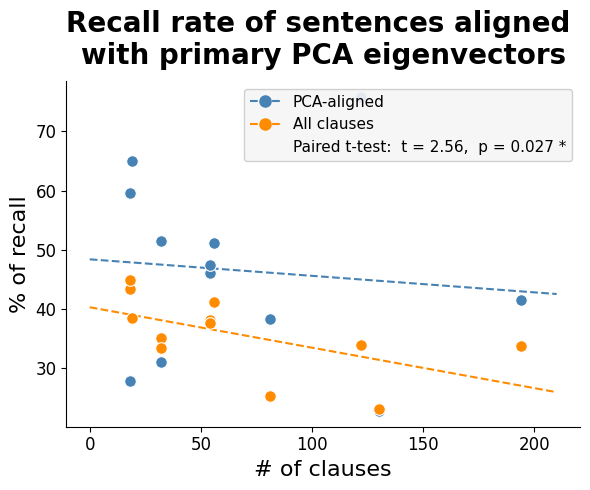

In [47]:
from scipy.stats import ttest_rel
from matplotlib.lines import Line2D

t_stat, p_paired = ttest_rel(mean_recall, mean_all_clauses_recall)
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_paired:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))

x_reg = np.linspace(0, 210, 300)

ax.scatter(clauses, mean_recall, color='steelblue', s=70, zorder=3,
           edgecolors='white', linewidths=0.8, label="PCA-aligned")
ax.plot(x_reg, intercept + slope * x_reg, "--", color="steelblue", lw=1.5)

ax.scatter(clauses, mean_all_clauses_recall, color='darkorange', s=70, zorder=3,
           edgecolors='white', linewidths=0.8, label="All clauses")
ax.plot(x_reg, intercept2 + slope2 * x_reg, "--", color="darkorange", lw=1.5)

ax.set_title("Recall rate of sentences aligned \nwith primary PCA eigenvectors",
             size=20, pad=12, fontweight="bold")
ax.set_xlabel("# of clauses", size=16)
ax.set_ylabel("% of recall", size=16)
ax.tick_params(labelsize=12)
ax.spines[['top', 'right']].set_visible(False)

p_str = f"p = {p_paired:.3f}" if p_paired >= 0.05 else f"p = {p_paired:.3f} *"
handles = [
    Line2D([0], [0], marker='o', color='steelblue', markerfacecolor='steelblue',
           markersize=8, linestyle='--', lw=1.5, label='PCA-aligned'),
    Line2D([0], [0], marker='o', color='darkorange', markerfacecolor='darkorange',
           markersize=8, linestyle='--', lw=1.5, label='All clauses'),
    Line2D([0], [0], color='none',
           label=f'Paired t-test:  t = {t_stat:.2f},  {p_str}'),
]
ax.legend(handles=handles, fontsize=11, loc='upper right',
          frameon=True, facecolor='#f5f5f5', edgecolor='#ccc', framealpha=0.9)

plt.tight_layout()
plt.show()


In [48]:
from scipy.stats import ttest_rel, t as t_dist
import numpy as np

x = np.array(mean_recall)
y_arr = np.array(mean_all_clauses_recall)
diff  = x - y_arr
n     = len(diff)

# ── paired t-test ──
t_stat, p_paired = ttest_rel(x, y_arr)
df       = n - 1
se_diff  = diff.std(ddof=1) / np.sqrt(n)
ci_low   = diff.mean() - t_dist.ppf(0.975, df) * se_diff
ci_high  = diff.mean() + t_dist.ppf(0.975, df) * se_diff
cohen_d  = diff.mean() / diff.std(ddof=1)
t_crit   = t_dist.ppf(0.975, df)
power    = 1 - t_dist.cdf(t_crit, df, loc=abs(t_stat)) + t_dist.cdf(-t_crit, df, loc=abs(t_stat))

print("=" * 55)
print("  PAIRED T-TEST")
print("=" * 55)
print(f"  n              = {n}")
print(f"  mean diff      = {diff.mean():.4f}  (PCA − all)")
print(f"  SE             = {se_diff:.4f}")
print(f"  t({df})         = {t_stat:.4f}")
print(f"  p (two-tailed) = {p_paired:.4f}")
print(f"  95% CI on diff = [{ci_low:.4f}, {ci_high:.4f}]")
print(f"  Cohen's d      = {cohen_d:.4f}  ({'small' if abs(cohen_d)<0.5 else 'medium' if abs(cohen_d)<0.8 else 'large'})")
print(f"  Power          = {power:.4f}  (α=0.05, parametric)")

# ── permutation test ──
n_perm   = 10000
t_perm   = np.zeros(n_perm)
for i in range(n_perm):
    signs      = np.random.choice([-1, 1], size=n)
    d_perm     = diff * signs
    t_perm[i]  = d_perm.mean() / (d_perm.std(ddof=1) / np.sqrt(n))
p_perm = np.mean(np.abs(t_perm) >= np.abs(t_stat))

print(f"\n  PERMUTATION TEST (n={n_perm})")
print(f"  p = {p_perm:.4f}")

# ── bootstrap ──
n_boot      = 10000
boot_diffs  = np.zeros(n_boot)
boot_t      = np.zeros(n_boot)
boot_d      = np.zeros(n_boot)
for i in range(n_boot):
    idx          = np.random.choice(n, n, replace=True)
    d_b          = diff[idx]
    boot_diffs[i] = d_b.mean()
    boot_t[i]    = d_b.mean() / (d_b.std(ddof=1) / np.sqrt(n))
    boot_d[i]    = d_b.mean() / d_b.std(ddof=1)

ci_low_b   = np.percentile(boot_diffs, 2.5)
ci_high_b  = np.percentile(boot_diffs, 97.5)
p_boot     = 2 * min(np.mean(boot_diffs <= 0), np.mean(boot_diffs >= 0))
d_boot_ci  = [np.percentile(boot_d, 2.5), np.percentile(boot_d, 97.5)]
t_crit_b   = t_dist.ppf(0.975, df)
power_boot = np.mean(np.abs(boot_t) >= t_crit_b)

print(f"\n  BOOTSTRAP (n={n_boot})")
print(f"  p (two-tailed)       = {p_boot:.4f}")
print(f"  mean diff            = {boot_diffs.mean():.4f}")
print(f"  95% CI on mean diff  = [{ci_low_b:.4f}, {ci_high_b:.4f}]")
print(f"  Cohen's d            = {boot_d.mean():.4f}  ({'small' if abs(boot_d.mean())<0.5 else 'medium' if abs(boot_d.mean())<0.8 else 'large'})")
print(f"  95% CI on Cohen's d  = [{d_boot_ci[0]:.4f}, {d_boot_ci[1]:.4f}]")
print(f"  Bootstrap power      = {power_boot:.4f}")
print("=" * 55)


  PAIRED T-TEST
  n              = 12
  mean diff      = 10.8102  (PCA − all)
  SE             = 4.2221
  t(11)         = 2.5604
  p (two-tailed) = 0.0265
  95% CI on diff = [1.5174, 20.1031]
  Cohen's d      = 0.7391  (medium)
  Power          = 0.6372  (α=0.05, parametric)

  PERMUTATION TEST (n=10000)
  p = 0.0213

  BOOTSTRAP (n=10000)
  p (two-tailed)       = 0.0056
  mean diff            = 10.8631
  95% CI on mean diff  = [3.2362, 19.0503]
  Cohen's d            = 0.8432  (large)
  95% CI on Cohen's d  = [0.2441, 1.7036]
  Bootstrap power      = 0.6962


In [49]:
recall_threshold = 0.5


def calculate_recall_probability_matrix(index, salient_embedding):
    n_participants = len(recall_emb_all[index])
    n_clauses = len(salient_embedding)
    recall_matrix = np.zeros((n_participants, n_clauses))

    print(f"story {index+1} start.")

    for j, clause in enumerate(salient_embedding):
        for k in np.arange(n_participants):
            for recall_clause_emb in recall_emb_all[index][k]:
                distance = cosine(recall_clause_emb, clause)
                if distance < recall_threshold:
                    recall_matrix[k, j] = 1.0
                    break

    clause_pct      = np.round(100 * recall_matrix.mean(axis=0), 2).tolist()  # per-clause %, unchanged from before
    participant_pct = (100 * recall_matrix.mean(axis=1)).tolist()             # per-participant %, NEW

    return clause_pct, participant_pct


recall_data             = [[] for i in np.arange(12)]
recall_data_participant = [[] for i in np.arange(12)]

for i in np.arange(12):
    salient_idx_narrative = salient_idx[i]
    salient_embedding = [story_emb_all[i][j] for j in salient_idx_narrative]

    ## compare with recalls and get the recall rate.
    recall_data[i], recall_data_participant[i] = calculate_recall_probability_matrix(i, salient_embedding)


all_clauses_recall             = []
all_clauses_recall_participant = []

for i in np.arange(12):
    all_embedding = story_emb_all[i]   # all clauses, not just salient
    clause_pct, participant_pct = calculate_recall_probability_matrix(i, all_embedding)
    all_clauses_recall.append(clause_pct)
    all_clauses_recall_participant.append(participant_pct)


story 1 start.
story 2 start.
story 3 start.
story 4 start.
story 5 start.
story 6 start.
story 7 start.
story 8 start.
story 9 start.
story 10 start.
story 11 start.
story 12 start.
story 1 start.
story 2 start.
story 3 start.
story 4 start.
story 5 start.
story 6 start.
story 7 start.
story 8 start.
story 9 start.
story 10 start.
story 11 start.
story 12 start.


Story 1: PCA-aligned mean=65.00, SE=2.959  |  All clauses mean=38.47, SE=2.029
Story 2: PCA-aligned mean=27.86, SE=3.210  |  All clauses mean=43.45, SE=2.709
Story 3: PCA-aligned mean=59.57, SE=2.412  |  All clauses mean=44.94, SE=1.859
Story 4: PCA-aligned mean=31.00, SE=4.648  |  All clauses mean=35.12, SE=1.926
Story 5: PCA-aligned mean=51.49, SE=2.581  |  All clauses mean=33.35, SE=1.740
Story 6: PCA-aligned mean=51.17, SE=2.785  |  All clauses mean=41.11, SE=1.639
Story 7: PCA-aligned mean=46.12, SE=3.130  |  All clauses mean=38.23, SE=1.687
Story 8: PCA-aligned mean=47.40, SE=2.338  |  All clauses mean=37.72, SE=1.794
Story 9: PCA-aligned mean=22.80, SE=1.811  |  All clauses mean=23.08, SE=1.358
Story 10: PCA-aligned mean=75.81, SE=1.958  |  All clauses mean=33.85, SE=1.265
Story 11: PCA-aligned mean=41.55, SE=2.063  |  All clauses mean=33.73, SE=1.474
Story 12: PCA-aligned mean=38.33, SE=2.566  |  All clauses mean=25.30, SE=1.749


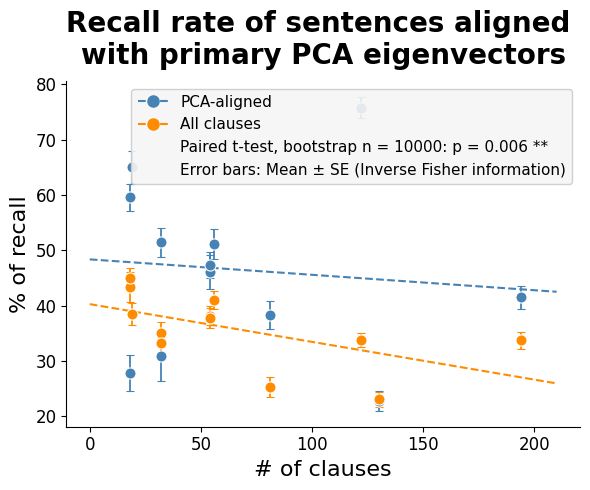

In [55]:
from scipy.stats import ttest_rel
from matplotlib.lines import Line2D

# ── compute per-story mean recall rate + Fisher-information SE (from participants) ──
mean_recall = [np.mean(story_values) for story_values in recall_data_participant]
se_recall_pca = [
    np.std(story_values, ddof=1) / np.sqrt(len(story_values))
    for story_values in recall_data_participant
]

mean_all_clauses_recall = [np.mean(story_values) for story_values in all_clauses_recall_participant]
se_recall_all = [
    np.std(story_values, ddof=1) / np.sqrt(len(story_values))
    for story_values in all_clauses_recall_participant
]

for i in range(12):
    print(
        f"Story {i+1}: "
        f"PCA-aligned mean={mean_recall[i]:.2f}, SE={se_recall_pca[i]:.3f}  |  "
        f"All clauses mean={mean_all_clauses_recall[i]:.2f}, SE={se_recall_all[i]:.3f}"
    )

# ── plot ──────────────────────────────────────────────────────────────────
t_stat, p_paired = ttest_rel(mean_recall, mean_all_clauses_recall)

fig, ax = plt.subplots(figsize=(6, 5))

x_reg = np.linspace(0, 210, 300)

ax.errorbar(clauses, mean_recall, yerr=se_recall_pca,
            fmt='o', color='steelblue', ecolor='steelblue', elinewidth=1.3,
            capsize=3, markersize=8, zorder=3, markeredgecolor='white',
            markeredgewidth=0.8)
ax.plot(x_reg, intercept + slope * x_reg, "--", color="steelblue", lw=1.5)

ax.errorbar(clauses, mean_all_clauses_recall, yerr=se_recall_all,
            fmt='o', color='darkorange', ecolor='darkorange', elinewidth=1.3,
            capsize=3, markersize=8, zorder=3, markeredgecolor='white',
            markeredgewidth=0.8)
ax.plot(x_reg, intercept2 + slope2 * x_reg, "--", color="darkorange", lw=1.5)

ax.set_title("Recall rate of sentences aligned \nwith primary PCA eigenvectors",
             size=20, pad=12, fontweight="bold")
ax.set_xlabel("# of clauses", size=16)
ax.set_ylabel("% of recall", size=16)
ax.tick_params(labelsize=12)
ax.spines[['top', 'right']].set_visible(False)

p_str      = f"p = {p_paired:.3f}" if p_paired >= 0.05 else f"p = {p_paired:.3f} *"
p_boot_str = f"p = {p_boot:.3f}"   if p_boot   >= 0.05 else f"p = {p_boot:.3f} **"

handles = [
    Line2D([0], [0], marker='o', color='steelblue', markerfacecolor='steelblue',
           markersize=8, linestyle='--', lw=1.5, label='PCA-aligned'),
    Line2D([0], [0], marker='o', color='darkorange', markerfacecolor='darkorange',
           markersize=8, linestyle='--', lw=1.5, label='All clauses'),
    Line2D([0], [0], color='none',
           label=f'Paired t-test, bootstrap n = 10000: {p_boot_str}'),
    Line2D([0], [0], color='none', label='Error bars: Mean ± SE (Inverse Fisher information)'),
]
ax.legend(handles=handles, fontsize=11, loc='upper right',
          frameon=True, facecolor='#f5f5f5', edgecolor='#ccc', framealpha=0.9)

plt.tight_layout()
plt.savefig('pca_recall_vs_all.png', dpi=150, bbox_inches='tight')
plt.show()



## Distribution of those highly recalled clauses.

In [20]:
recall_threshold = 0.5

clause_recall_all = []
for i in range(12):
    n_clauses      = len(story_emb_all[i])
    n_participants = len(recall_emb_all[i])

    clause_recall = np.zeros(n_clauses)
    for j in range(n_clauses):
        clause_emb = story_emb_all[i][j]
        for k in range(n_participants):
            for recall_emb in recall_emb_all[i][k]:
                if cosine(recall_emb, clause_emb) < recall_threshold:
                    clause_recall[j] += 1.0 / n_participants
                    break
    clause_recall_all.append(np.round(clause_recall * 100, 2))
    print(f"Story {i+1} done.")


Story 1 done.
Story 2 done.
Story 3 done.
Story 4 done.
Story 5 done.
Story 6 done.
Story 7 done.
Story 8 done.
Story 9 done.
Story 10 done.
Story 11 done.
Story 12 done.


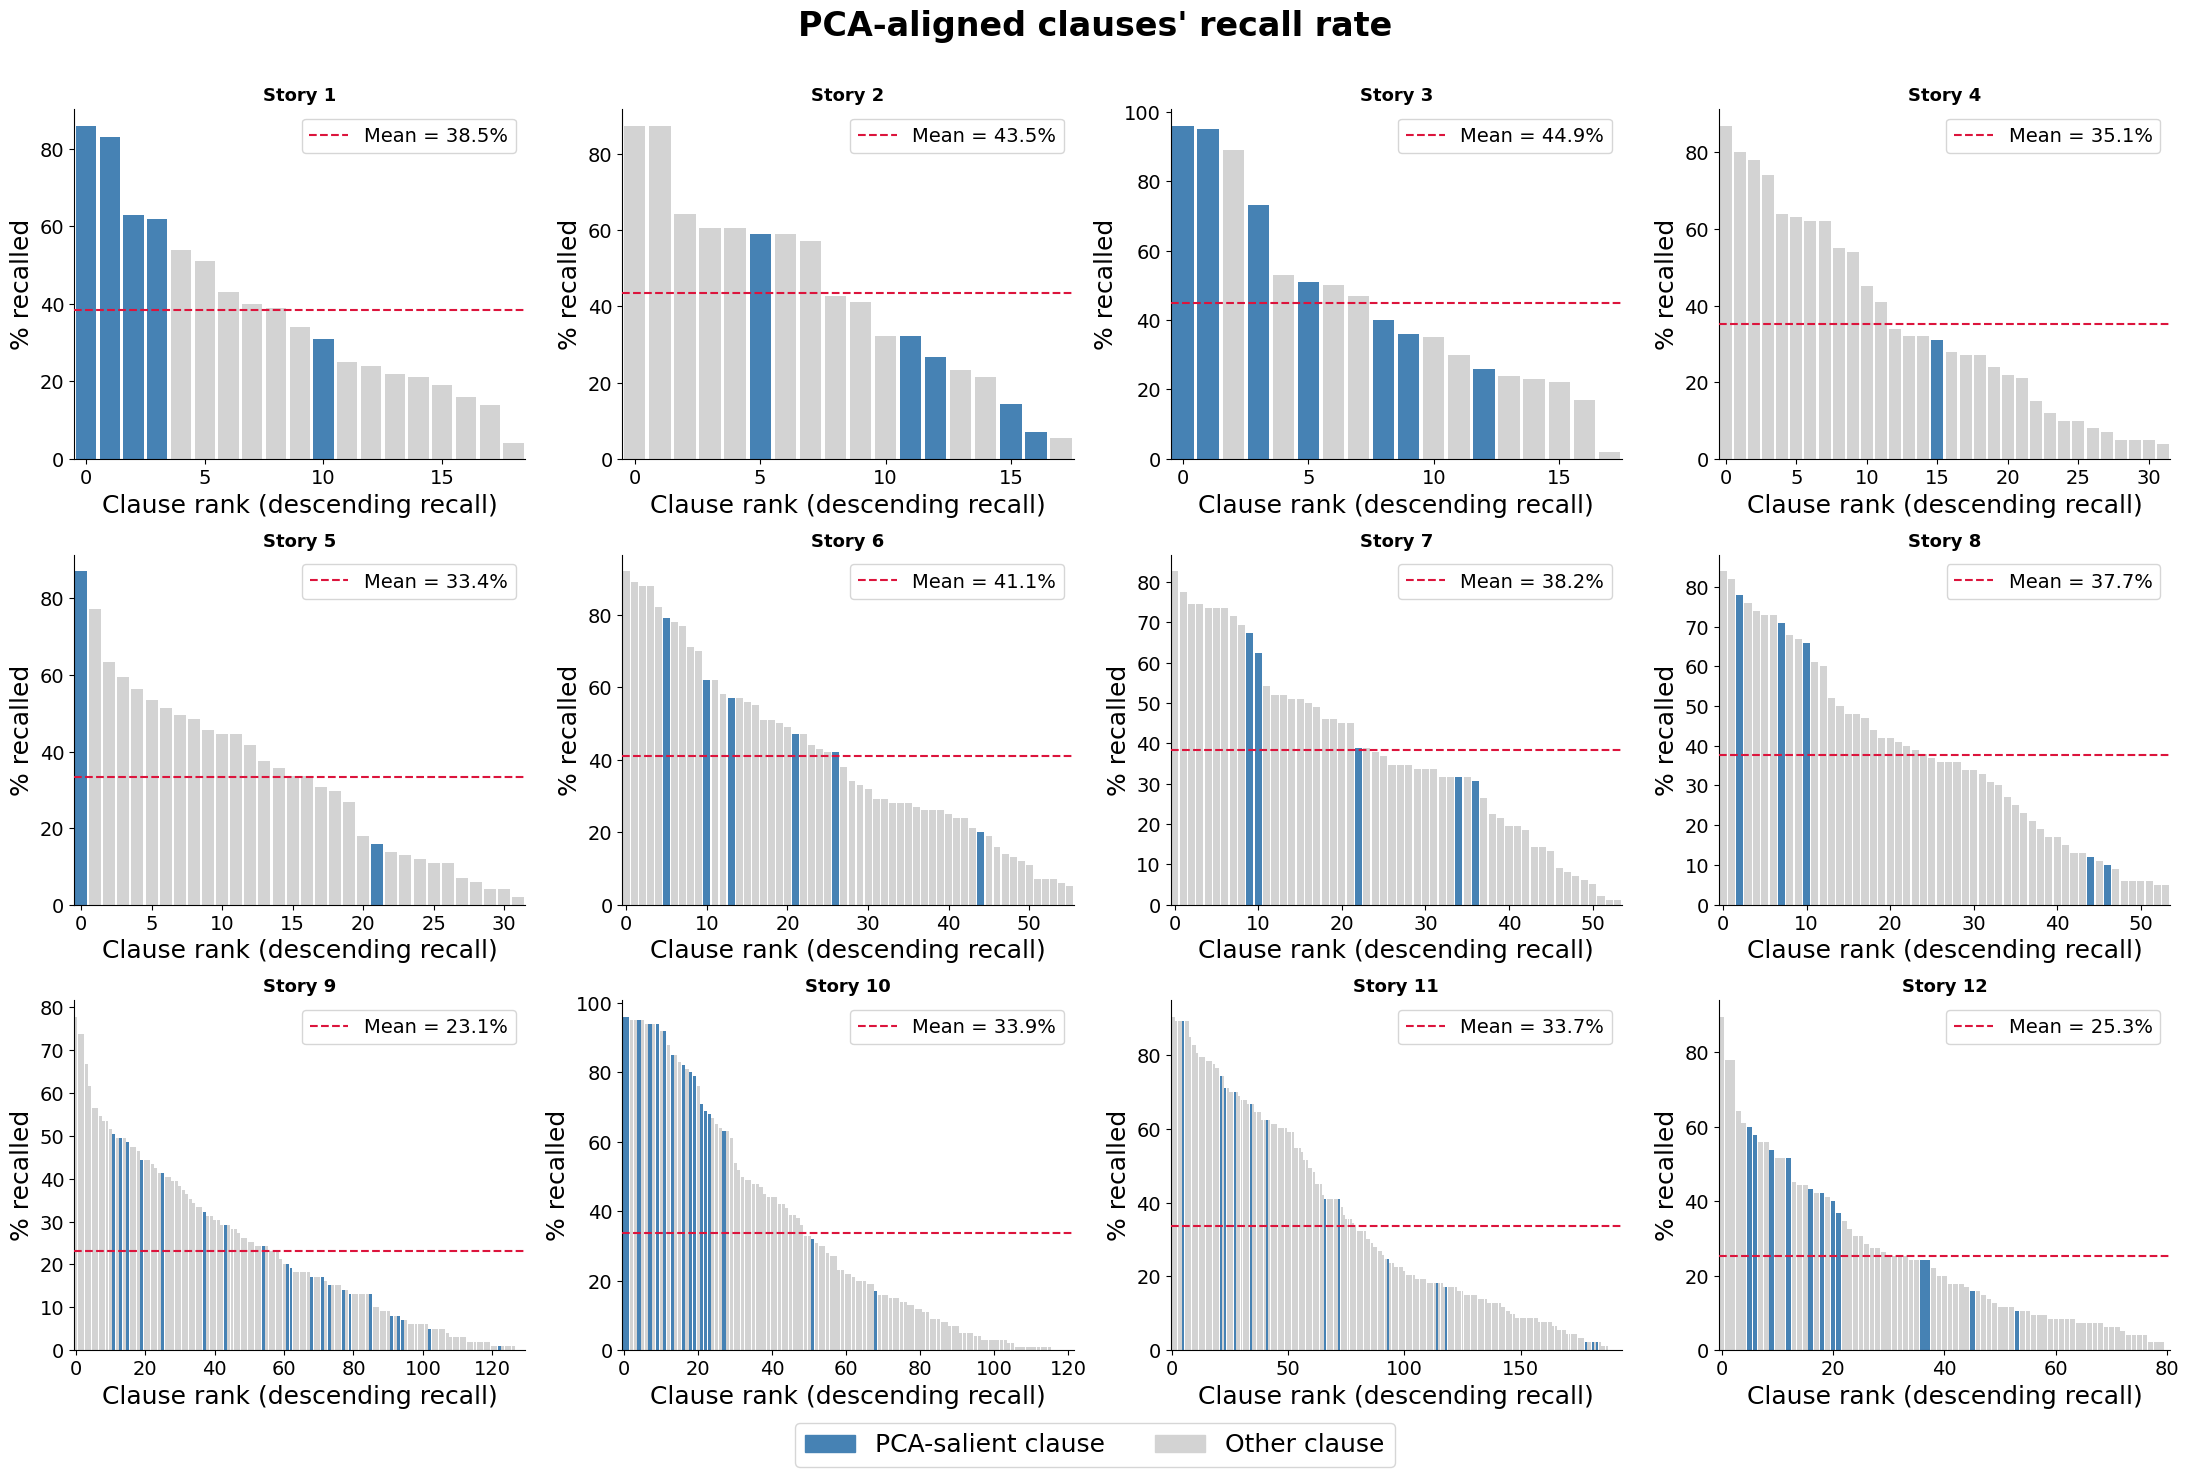

In [28]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
axes = axes.flatten()

for i in range(12):
    clause_recall = clause_recall_all[i]
    mean_recall_i = np.mean(clause_recall)

    sorted_order  = np.argsort(clause_recall)[::-1]
    sorted_recall = clause_recall[sorted_order]

    salient_set = set(salient_idx_all[i])
    colors = ['steelblue' if sorted_order[j] in salient_set else 'lightgray'
              for j in range(len(clause_recall))]

    ax = axes[i]
    ax.bar(range(len(clause_recall)), sorted_recall, color=colors, width=0.85, zorder=2)
    ax.axhline(mean_recall_i, color='crimson', linestyle='--', lw=1.5, zorder=3,
               label=f"Mean = {mean_recall_i:.1f}%")

    ax.set_title(f"Story {i+1}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Clause rank (descending recall)", fontsize=18)
    ax.set_ylabel("% recalled", fontsize=18)
    ax.tick_params(labelsize=14)
    ax.set_xlim(-0.5, len(clause_recall) - 0.5)
    ax.legend(fontsize=14, loc='upper right')
    ax.spines[['top', 'right']].set_visible(False)

legend_handles = [
    Patch(color='steelblue', label='PCA-salient clause'),
    Patch(color='lightgray',  label='Other clause'),
]
fig.legend(handles=legend_handles, fontsize=18, loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.04))

plt.suptitle("PCA-aligned clauses' recall rate", fontsize=24,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [37]:
ratios = []
for i in range(12):
    clause_recall = clause_recall_all[i]
    mean_recall_i = np.mean(clause_recall)
    salient_set   = set(salient_idx_all[i])

    above = sum(1 for j in salient_set if clause_recall[j] > mean_recall_i)
    below = sum(1 for j in salient_set if clause_recall[j] <= mean_recall_i)
    ratio = above / below if below > 0 else np.inf
    ratios.append(ratio)

    print(f"Story {i+1}: above = {above}, below = {below}, ratio = {ratio:.2f}")

print(f"\nMean ratio: {np.mean(ratios):.2f}")


Story 1: above = 4, below = 1, ratio = 4.00
Story 2: above = 1, below = 4, ratio = 0.25
Story 3: above = 4, below = 3, ratio = 1.33
Story 4: above = 0, below = 1, ratio = 0.00
Story 5: above = 1, below = 1, ratio = 1.00
Story 6: above = 5, below = 1, ratio = 5.00
Story 7: above = 3, below = 2, ratio = 1.50
Story 8: above = 3, below = 2, ratio = 1.50
Story 9: above = 8, below = 13, ratio = 0.62
Story 10: above = 14, below = 2, ratio = 7.00
Story 11: above = 8, below = 6, ratio = 1.33
Story 12: above = 8, below = 4, ratio = 2.00

Mean ratio: 2.13


In [29]:
## do the same for gist clauses.
index_main_story_1 = [1, 2, 7, 8, 9, 12, 13, 16, 17, 19]
index_main_story_2 = [1, 2, 5, 11, 12, 13, 15, 16]   # deleted two clauses not going to be indispensable for the story flow.
index_main_story_3 = [1, 4, 5, 7, 9, 11, 12, 13, 16, 18]    ## hard to tell the indispensable clauses, to make the story whole.

index_main_story_4 = [1, 4, 6, 12, 13, 15, 19, 20, 25, 26, 28, 30]  ## added 6, 25. 
index_main_story_5 = [1, 4, 6, 8, 10, 12, 13, 15, 20, 25, 26, 28, 30]  ## added 6.

index_main_story_6 = [1, 6, 12, 14, 15, 19, 23, 25, 27, 28, 38, 40, 47, 49, 54]  ## delete some dispensable clauses to tell the story.
index_main_story_7 = [1, 3, 5, 8, 10, 11, 14, 35, 36, 41, 42, 49, 51, 53]  # deleted 18, 22, 29. added 41, 45.  with time causal clauses in.
index_main_story_8 = [1, 3, 5, 10, 15, 24, 26, 29, 31, 36, 39, 46, 51, 53]   # deleted 24. added 27 and 29.

index_main_story_9 = [1, 5, 7, 10, 11, 13, 14, 23, 33, 41, 44, 76, 77, 80, 108, 120, 128] # added 44, 120. deleted 112.
index_main_story_10 = [1, 3, 10, 12, 15, 20, 29, 30, 39, 40, 41, 46, 50, 58, 70, 77, 80, 84, 90, 95, 100, 108, 121] # deleted 35, 75, 80, 115.
index_main_story_11 = [1, 4, 5, 7, 19, 21, 24, 27, 128, 163, 166, 190]
index_main_story_12 = [1, 4, 6, 9, 12, 18, 22, 32, 46, 58, 64, 74, 80] ## deleted 15, 13, 42. added 45, 63. 


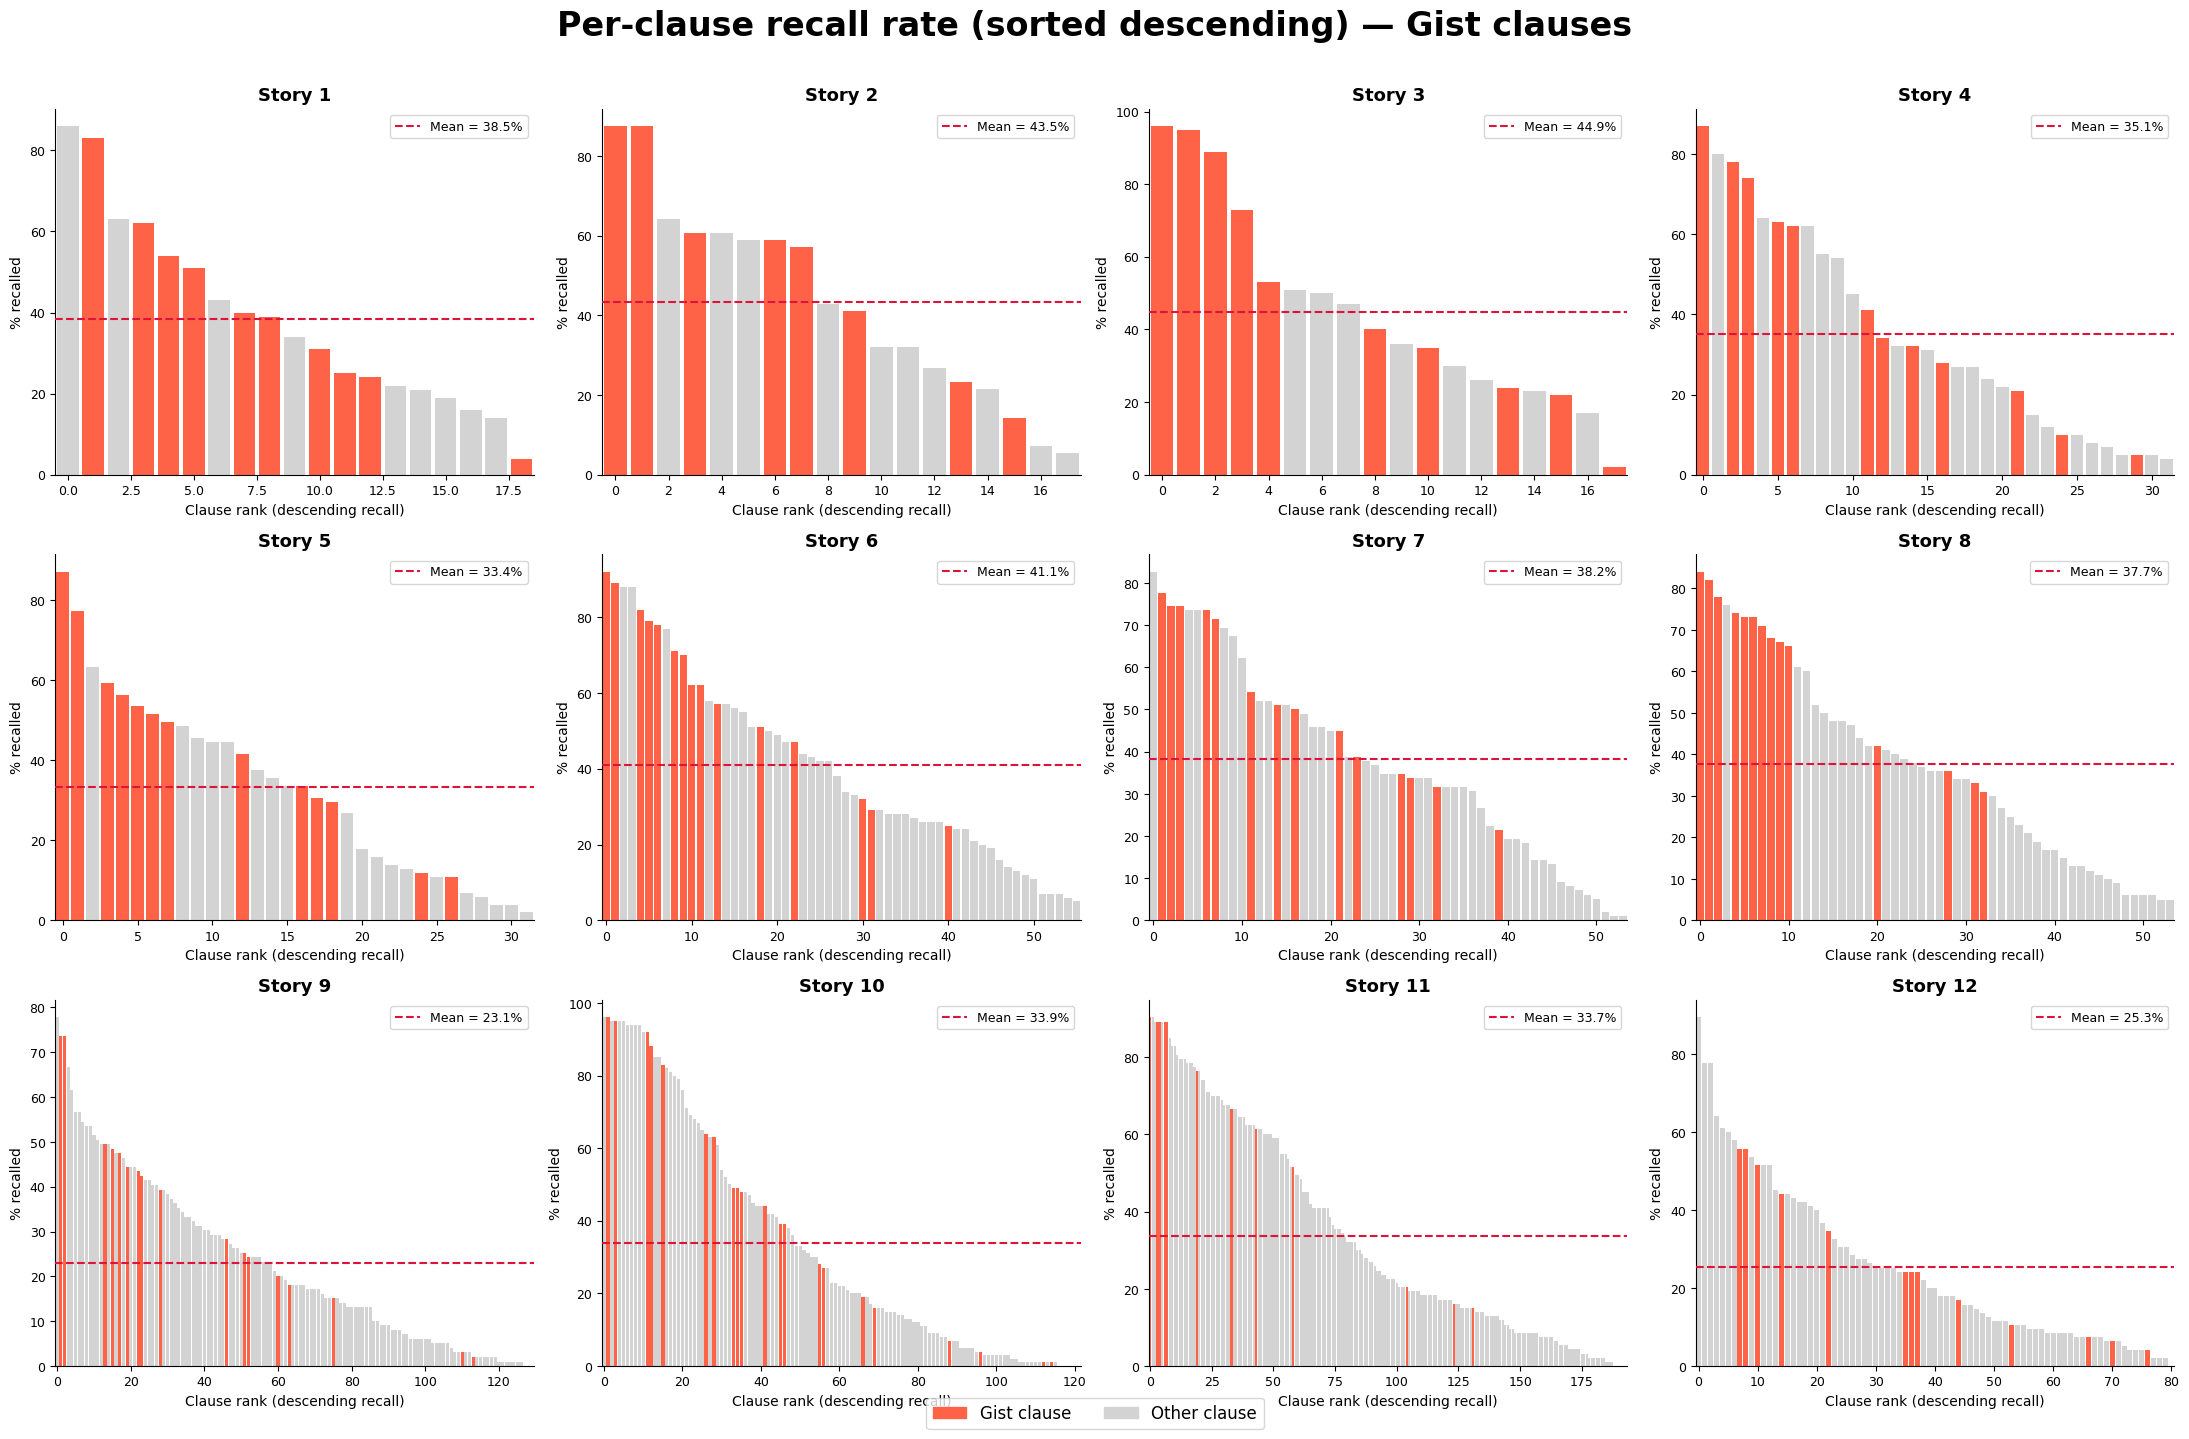

In [31]:
# collect gist indices (1-indexed → 0-indexed)
index_main_all = [
    index_main_story_1,  index_main_story_2,  index_main_story_3,
    index_main_story_4,  index_main_story_5,  index_main_story_6,
    index_main_story_7,  index_main_story_8,  index_main_story_9,
    index_main_story_10, index_main_story_11, index_main_story_12,
]
index_main_0 = [[idx - 1 for idx in story] for story in index_main_all]

from matplotlib.patches import Patch

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
axes = axes.flatten()

for i in range(12):
    clause_recall = clause_recall_all[i]
    mean_recall_i = np.mean(clause_recall)

    sorted_order  = np.argsort(clause_recall)[::-1]
    sorted_recall = clause_recall[sorted_order]

    gist_set = set(index_main_0[i])
    colors = ['tomato' if sorted_order[j] in gist_set else 'lightgray'
              for j in range(len(clause_recall))]

    ax = axes[i]
    ax.bar(range(len(clause_recall)), sorted_recall, color=colors, width=0.85, zorder=2)
    ax.axhline(mean_recall_i, color='crimson', linestyle='--', lw=1.5, zorder=3,
               label=f"Mean = {mean_recall_i:.1f}%")

    ax.set_title(f"Story {i+1}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Clause rank (descending recall)", fontsize=10)
    ax.set_ylabel("% recalled", fontsize=10)
    ax.tick_params(labelsize=9)
    ax.set_xlim(-0.5, len(clause_recall) - 0.5)
    ax.legend(fontsize=9, loc='upper right')
    ax.spines[['top', 'right']].set_visible(False)

legend_handles = [
    Patch(color='tomato',    label='Gist clause'),
    Patch(color='lightgray', label='Other clause'),
]
fig.legend(handles=legend_handles, fontsize=12, loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.01))

plt.suptitle("Per-clause recall rate (sorted descending) — Gist clauses",
             fontsize=24, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [32]:
### overlapping of the PCA-aligned clauses with Gist.

for i in range(12):
    salient_set = set(salient_idx_all[i])
    gist_set    = set(index_main_0[i])
    overlap     = salient_set & gist_set
    pct         = 100 * len(overlap) / len(salient_set) if salient_set else 0
    print(f"Story {i+1}: {len(overlap)}/{len(salient_set)} PCA-salient clauses are gist  ({pct:.1f}%)")

# overall
all_salient = [idx for s in salient_idx_all for idx in s]
all_gist    = [idx for s in index_main_0    for idx in s]
overlap_all = set(all_salient) & set(all_gist)  # not meaningful across stories

# per-story pooled
total_salient  = sum(len(s) for s in salient_idx_all)
total_overlap  = sum(len(set(salient_idx_all[i]) & set(index_main_0[i])) for i in range(12))
print(f"\nOverall: {total_overlap}/{total_salient} ({100*total_overlap/total_salient:.1f}%)")


Story 1: 3/5 PCA-salient clauses are gist  (60.0%)
Story 2: 1/5 PCA-salient clauses are gist  (20.0%)
Story 3: 4/7 PCA-salient clauses are gist  (57.1%)
Story 4: 0/1 PCA-salient clauses are gist  (0.0%)
Story 5: 1/2 PCA-salient clauses are gist  (50.0%)
Story 6: 3/6 PCA-salient clauses are gist  (50.0%)
Story 7: 0/5 PCA-salient clauses are gist  (0.0%)
Story 8: 3/5 PCA-salient clauses are gist  (60.0%)
Story 9: 3/21 PCA-salient clauses are gist  (14.3%)
Story 10: 2/16 PCA-salient clauses are gist  (12.5%)
Story 11: 0/14 PCA-salient clauses are gist  (0.0%)
Story 12: 3/12 PCA-salient clauses are gist  (25.0%)

Overall: 23/99 (23.2%)
